In [2]:
import random

"""random probability setting"""
rand_prb = 0.8


class HagetakaEnv:
    def __init__(self, player_types=None):
        """
        player_types: 各プレイヤーのタイプを指定するリスト。例: ['random', 'stable', 'mimic']
        """
        self.n_players = 4
        self.n_cards = 15
        self.player_cards = [list(range(1, self.n_cards + 1)) for _ in range(self.n_players)]  # 各プレイヤーの持ちカード
        self.score_cards = [-5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
        random.shuffle(self.score_cards)
        self.current_score_index = 0
        self.scores = [0] * self.n_players  # 各プレイヤーのスコア
        if player_types is None:
            player_types = ['random', 'random', 'random']
        self.player_types = player_types
        self.past_actions = [[] for _ in range(self.n_players)]  # 各プレイヤーの過去の行動

    def reset(self):
        """環境のリセット"""
        self.player_cards = [list(range(1, self.n_cards + 1)) for _ in range(self.n_players)]  # 手持ちカードのリセット
        random.shuffle(self.score_cards)  # 得点カードをシャッフル
        self.current_score_index = 0
        self.scores = [0] * self.n_players  # スコアのリセット
        self.past_actions = [[] for _ in range(self.n_players)]  # 過去の行動をリセット
        return self._get_flat_state()

    def _get_flat_state(self):
        """状態をフラットな形式に変換"""
        padded_player_cards = [player + [-1] * (self.n_cards - len(player)) for player in self.player_cards]
        flat_state = (
            sum(padded_player_cards, [])  # プレイヤーの手持ちカードを平坦化
            + self.score_cards
            + [self.current_score_index]
            + self.scores
        )
        return flat_state

    def stable_player_action(self, player_index):
        """安定プレイヤの行動選択: 高得点カードなら高いカードを、負の得点カードなら低いカードを選ぶ"""
        available_cards = self.player_cards[player_index]
        score_card = self.score_cards[self.current_score_index]
        if score_card > 0:
            chosen_card = max(available_cards)  # 高得点カードなら最大値を選ぶ
        else:
            chosen_card = min(available_cards)  # 負の得点カードなら最小値を選ぶ
        return chosen_card

    def random_player_action(self, player_index):
        """ランダムプレイヤの行動選択"""
        available_cards = self.player_cards[player_index]
        chosen_card = random.choice(available_cards)  # 手持ちのカードの中からランダムに1枚を選択
        return chosen_card
    
    def stable_or_random_player_action(self, player_index):
        """Choose stable or random"""
        available_cards = self.player_cards[player_index]
        rand_value = random.random()
        if rand_value < rand_prb:
            score_card = self.score_cards[self.current_score_index]
            if score_card > 0:
                chosen_card = max(available_cards)
            else:
                chosen_card = min(available_cards)
        else:
            chosen_card = random.choice(available_cards)
        return chosen_card

    def negative_avoidance_player_action(self, player_index):
        """マイナス回避戦略：マイナスカードが出たら持っている一番大きいカードを出す"""
        available_cards = self.player_cards[player_index]
        score_card = self.score_cards[self.current_score_index]
        if score_card < 0:
            chosen_card = max(available_cards)
        else:
            chosen_card = random.choice(available_cards)
        return chosen_card
    
    def step(self, action):
        """ゲームの1ステップを実行"""
        actions = [action]  # エージェントの行動

        # プレイヤー2～4の行動を選択
        for i in range(1, self.n_players):
            if len(self.player_cards[i]) > 0:
                chosen_action = 0
                if self.player_types[i - 1] == 'random':
                    chosen_action = self.random_player_action(i)  # ランダムプレイヤの行動選択
                elif self.player_types[i - 1] == 'stable':
                    chosen_action = self.stable_player_action(i)  # 安定プレイヤの行動選択
                elif self.player_types[i - 1] == 'sta_rand':
                    chosen_action = self.stable_or_random_player_action(i)
                elif self.player_types[i - 1] == 'negavoid':
                    chosen_action = self.negative_avoidance_player_action(i)
                actions.append(chosen_action)
            else:
                actions.append(-1)  # カードが残っていない場合は-1

        score_card = self.score_cards[self.current_score_index]
        unique_actions = list(set(actions))

        # 勝者を決定（同じカードを出したプレイヤは無効）
        if len(unique_actions) == 1:
            winner = actions.index(unique_actions[0])
        else:
            action_counts = [actions.count(action) for action in unique_actions]
            valid_actions = [action for action, count in zip(unique_actions, action_counts) if count == 1]

            if not valid_actions:
                winner = None  # 全員無効
            else:
                if score_card > 0:
                    winner = actions.index(max(valid_actions))  # 最大のカードを出したプレイヤが勝ち
                else:
                    winner = actions.index(min(valid_actions))  # 最小のカードを出したプレイヤが勝ち

        # 勝者がいればスコアを追加
        if winner is not None:
            self.scores[winner] += score_card

        # 過去の行動を記録
        for i, action in enumerate(actions):
            if action != -1:
                self.past_actions[i].append(action)

        # 出したカードを手持ちから削除(無効な行動も含む)
        for i, action in enumerate(actions):
            if action != -1 and action in self.player_cards[i]: 
                self.player_cards[i].remove(action)  # 選んだカードを手持ちから削除

        # 各プレイヤーの行動と得点カードをinfoに保存
        info = {
            'score_card': score_card,
            'player_cards': actions
        }
                

        self.current_score_index += 1  # 次の得点カードに進む
        done = self.current_score_index >= len(self.score_cards)  # ゲーム終了のチェック
        state = self._get_flat_state()
        reward = self.scores[0]  # 学習エージェントの報酬（プレイヤー1）
        return state, reward, done, info

    def is_terminal(self):
        """ゲームが終了しているかを返す"""
        return self.current_score_index >= len(self.score_cards)


In [3]:
#REINFORCEエージェント

import torch
import torch.optim as optim

class PolicyNetwork(torch.nn.Module):
    def __init__(self, state_size, action_size):
        super(PolicyNetwork, self).__init__()
        self.fc1 = torch.nn.Linear(state_size, 128)
        self.fc2 = torch.nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.softmax(self.fc2(x), dim=-1)  # Use softmax to ensure probabilities sum to 1
        return x

class REINFORCEAgent:
    def __init__(self, state_size, action_size, learning_rate=0.01):
        self.policy_network = PolicyNetwork(state_size, action_size)
        self.optimizer = optim.Adam(self.policy_network.parameters(), lr=learning_rate)
        self.action_size = action_size
        self.gamma = 0.99  # 割引率

        self.states = []
        self.actions = []
        self.rewards = []
        self.available_actions = list(range(action_size))  # 使用可能なカードリスト

    def reset(self):
        """エピソードの開始時に使用可能なカードをリセット"""
        self.available_actions = list(range(self.action_size))

    def get_action(self, state):
        """行動を選択し、選択されたカードは使用可能リストから除外"""
        state = torch.FloatTensor(state)
        action_probs = self.policy_network(state)

        # 使用可能なカードだけに対応する確率を抽出
        valid_probs = action_probs[self.available_actions]

        """

        # 確率が0にならないように正規化
        if valid_probs.sum().item() == 0 or torch.isnan(valid_probs).any():
            valid_probs = torch.ones_like(valid_probs) / len(valid_probs)
        else:
            epsilon = 1e-9
            valid_probs = valid_probs / (valid_probs.sum() + epsilon)

        action_dist = torch.distributions.Categorical(valid_probs)
        action_idx = action_dist.sample()



        # 確率が0にならないように正規化 + detachを削除
        # if valid_probs.sum().item() == 0 or torch.isnan(valid_probs).any():
        #    valid_probs = torch.ones_like(valid_probs) / len(valid_probs)
        # else:
        epsilon = 1e-9  # Add small epsilon for numerical stability
        valid_probs = valid_probs / (valid_probs.sum() + epsilon)

        action_dist = torch.distributions.Categorical(valid_probs)
        action_idx = action_dist.sample()

        """

   
        valid_probs = valid_probs / valid_probs.sum() 
        valid_probs[torch.isnan(valid_probs)] = 1 / len(valid_probs)  

        action_dist = torch.distributions.Categorical(valid_probs)
        action_idx = action_dist.sample()


        # 対応する実際のカードを取得（ここで +1 して1〜15の範囲に変換）
        action = self.available_actions[action_idx.item()] + 1

        # 選択されたカードを使用済みにする（リストから削除）
        self.available_actions.remove(action - 1)  # available_actionsは0〜14の範囲で管理

        return action, action_dist.log_prob(action_idx)


    def store_outcome(self, state, log_prob, reward):
        self.states.append(state)
        self.actions.append(log_prob)
        self.rewards.append(reward)

    def update_policy(self):
        """方策の更新"""
        R = 0
        rewards_discounted = []
        for r in reversed(self.rewards):
            R = r + self.gamma * R
            rewards_discounted.insert(0, R)

        # 報酬を標準化
        rewards_discounted = torch.FloatTensor(rewards_discounted)
        rewards_discounted = (rewards_discounted - rewards_discounted.mean()) / (rewards_discounted.std() + 1e-9)

        # 損失関数を計算して方策を更新
        loss = 0
        for log_prob, reward in zip(self.actions, rewards_discounted):
            loss -= log_prob * reward

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # メモリをリセット
        self.states = []
        self.actions = []
        self.rewards = []

Experiment 1/100 completed.
26.133333333333333
Experiment 2/100 completed.
18.466666666666665
Experiment 3/100 completed.
12.733333333333333
Experiment 4/100 completed.
27.333333333333332
Experiment 5/100 completed.
19.6
Experiment 6/100 completed.
19.733333333333334
Experiment 7/100 completed.
20.866666666666667
Experiment 8/100 completed.
26.866666666666667
Experiment 9/100 completed.
16.333333333333332
Experiment 10/100 completed.
14.666666666666666
Experiment 11/100 completed.
16.466666666666665
Experiment 12/100 completed.
25.533333333333335
Experiment 13/100 completed.
18.2
Experiment 14/100 completed.
13.333333333333334
Experiment 15/100 completed.
10.133333333333333
Experiment 16/100 completed.
22.866666666666667
Experiment 17/100 completed.
23.733333333333334
Experiment 18/100 completed.
20.533333333333335
Experiment 19/100 completed.
23.2
Experiment 20/100 completed.
26.0
Experiment 21/100 completed.
18.2
Experiment 22/100 completed.
20.6
Experiment 23/100 completed.
25.53333

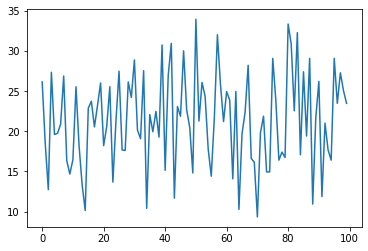

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import random

# トレーニングの実行例
n_steps = 1000  # 各実験でのステップ数
n_experiments = 100  # 実験回数
N_total = n_steps * n_experiments
gamma = 0.99  # 割引率

env = HagetakaEnv(player_types=['sta_rand', 'sta_rand', 'sta_rand'])  # 環境の初期化
state_size = len(env._get_flat_state())  # 状態の次元数を取得
action_size = 15  # 行動の数（カードの枚数）
agent = REINFORCEAgent(state_size, action_size)  # エージェントの初期化

avg_step_scores = []

# エージェントのトレーニング関数
def train_agent(agent, env, n_steps, n_experiments, gamma):
    """
    エージェントをトレーニングし、1000ステップの実験を100回繰り返し、各ステップの平均スコアをグラフ化する関数
    """

    # 各実験のステップごとのスコアを記録する配列
    step_scores = []

    for experiment in range(n_experiments):
        for step in range(n_steps):
            state = env.reset()  # 環境のリセット
            agent.reset()  # エージェントのリセット
            done = False
            total_reward = 0
            ex_score = []

            while not done:
                action, log_prob = agent.get_action(state)  # 行動を選択
                next_state, reward, done, _ = env.step(action)  # 環境で1ステップを実行

                agent.store_outcome(state, log_prob, reward)  # 結果をエージェントに保存
                state = next_state
                total_reward += reward  # 報酬を累積
                ex_score.append(reward)

        print(f'Experiment {experiment + 1}/{n_experiments} completed.')

        # 各ステップごとのスコアの平均を計算
        avg_step_scores.append(np.average(ex_score)) 
        
        print(avg_step_scores[experiment])

    # 平均スコアをグラフで出力
    # plot_average_step_scores(avg_step_scores, n_steps)
    
    # calculate averagescore
    plt.plot(avg_step_scores)
    
    return avg_step_scores
"""
# グラフをプロットする関数
def plot_average_step_scores(avg_step_scores, n_steps):
    steps = np.arange(1, n_steps + 1)
    plt.figure(figsize=(10, 6))

    # 各ステップの平均スコアをプロット
    plt.plot(steps, avg_step_scores, label='Average Score')

    plt.title('Average Score per Step Over 100 Experiments')
    plt.xlabel('Step')
    plt.ylabel('Average Score')
    plt.legend()
    plt.grid(True)
    plt.show()
"""




# トレーニングを実行
avg_step_scores = train_agent(agent, env, n_steps, n_experiments, gamma)



Episode 100/100000, Total Reward: 112
Episode 200/100000, Total Reward: 19

Average score after 200 episodes:
  Player 1: 10.26
  Player 2: 11.15
  Player 3: 5.02
  Player 4: 13.06
Episode 300/100000, Total Reward: 191
Episode 400/100000, Total Reward: 7

Average score after 400 episodes:
  Player 1: 10.89
  Player 2: 10.16
  Player 3: 4.22
  Player 4: 14.24
Episode 500/100000, Total Reward: 21
Episode 600/100000, Total Reward: 96

Average score after 600 episodes:
  Player 1: 10.64
  Player 2: 11.73
  Player 3: 4.22
  Player 4: 13.17
Episode 700/100000, Total Reward: 13
Episode 800/100000, Total Reward: -2

Average score after 800 episodes:
  Player 1: 11.34
  Player 2: 11.24
  Player 3: 4.88
  Player 4: 12.28
Episode 900/100000, Total Reward: 44
Episode 1000/100000, Total Reward: 90

Average score after 1000 episodes:
  Player 1: 10.93
  Player 2: 11.28
  Player 3: 4.19
  Player 4: 13.20
Episode 1100/100000, Total Reward: 70
Episode 1200/100000, Total Reward: 14

Average score after 

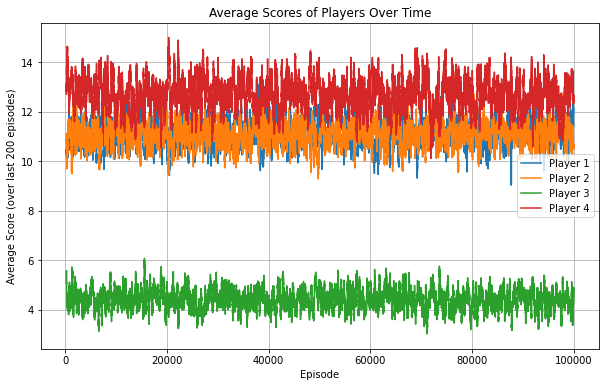

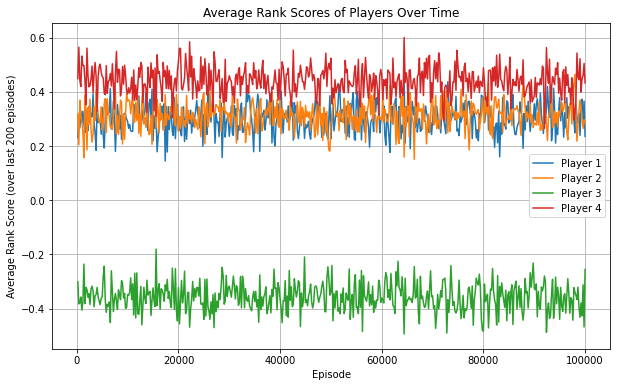

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random



# ラスト10エピソードの得点カードとプレイヤーのカードを表示する関数
def print_last_10_episodes(last_10_episodes):
    print("\nLast 10 Episodes - Score Cards and Player's Cards:")
    for idx, (score_cards, player_cards) in enumerate(last_10_episodes):
        print(f"\nEpisode {idx + 1}:")
        print(f"  Score Cards   : {' '.join(f'{card:>2}' for card in score_cards)}")
        for i, cards in enumerate(player_cards):
            print(f"  Player {i + 1} Cards: {' '.join(f'{card:>2}' for card in cards)}")

# エージェントのトレーニング関数
def train_agent(agent, env, n_episodes, gamma):
    """
    エージェントをトレーニングし、200エピソードごとにプレイヤーごとの平均スコアを計算してグラフ化する関数
    """

    player_scores = np.zeros((env.n_players, n_episodes))  # 各プレイヤーのスコアを記録する
    total_rewards = []  # 各エピソードでの累積報酬を保存するリスト
    last_10_episodes = []  # ラスト10エピソードのカード履歴を保存するリスト
    
    # 各プレイヤーの順位スコアの履歴を保存するリスト
    rank_scores_history = [[] for _ in range(env.n_players)]

    for episode in range(n_episodes):
        state = env.reset()  # 環境のリセット
        agent.reset()  # エピソードごとに使用可能なカードをリセット
        done = False
        total_reward = 0

        score_card_history = []  # 各エピソードの得点カードの順番
        player_card_history = [[] for _ in range(env.n_players)]  # 各プレイヤーが出したカードの順番

        while not done:
            action, log_prob = agent.get_action(state)  # 行動を選択
            next_state, reward, done, info = env.step(action)  # 環境で1ステップを実行

            # 出したカードの情報を保存
            score_card_history.append(info['score_card'])
            for i, card in enumerate(info['player_cards']):
                player_card_history[i].append(card)
            
            agent.store_outcome(state, log_prob, reward)  # 結果をエージェントに保存
            state = next_state
            total_reward += reward  # 報酬を累積

        # プレイヤーごとのスコアを記録
        for i in range(env.n_players):
            player_scores[i][episode] = env.scores[i]  # このエピソードでのスコアを保存
            
        # 各プレイヤーの順位スコアを計算
        scores = env.scores
        sorted_indices = np.argsort(scores)[::-1]  # スコア順にソートして順位を取得（降順）
        ranks = [0] * env.n_players
        rank_values = [1.0, 0.8, -0.1, -1.0]  # 各順位に対応するスコア
        for rank, player_index in enumerate(sorted_indices):
            ranks[player_index] = rank_values[rank]
            rank_scores_history[player_index].append(rank_values[rank])        

        # エージェントに順位報酬を与える
        rank_reward = rank_values[sorted_indices.tolist().index(0)]  # エージェントの順位に対応する報酬
        agent.rewards[-1] = rank_reward  # エージェントの最終ステップに順位報酬を反映
            
        agent.update_policy()  # エピソード終了後に方策を更新
        total_rewards.append(total_reward)

        # 進捗を表示
        if (episode + 1) % 100 == 0:
            print(f'Episode {episode + 1}/{n_episodes}, Total Reward: {total_reward}')

        # 200エピソードごとに平均スコアを計算して表示
        if (episode + 1) % 200 == 0:
            print(f'\nAverage score after {episode + 1} episodes:')
            avg_scores = player_scores[:, episode-199:episode].mean(axis=1)
            for i, avg_score in enumerate(avg_scores):
                print(f"  Player {i + 1}: {avg_score:.2f}")

        # ラスト10エピソードのカード履歴を保存
        if len(last_10_episodes) >= 10:
            last_10_episodes.pop(0)  # 最後の10エピソードのみ保持するため、古いエピソードを削除
        last_10_episodes.append((score_card_history, player_card_history))


    # ラスト10エピソードの結果を表示
    print_last_10_episodes(last_10_episodes)

    # 最後に各プレイヤーの平均スコアをグラフで出力
    plot_average_scores(player_scores, n_episodes)
    
    # 200エピソードごとの順位スコアの平均をグラフで表示
    plot_rank_scores(rank_scores_history, n_episodes)

    return total_rewards

# グラフをプロットする関数
def plot_average_scores(player_scores, n_episodes):
    episodes = np.arange(1, n_episodes + 1)
    plt.figure(figsize=(10, 6))

    # 各プレイヤーのスコアの移動平均をプロット
    for i in range(player_scores.shape[0]):
        avg_scores = np.convolve(player_scores[i], np.ones(200)/200, mode='valid')  # 移動平均を計算
        plt.plot(np.arange(200, n_episodes + 1), avg_scores, label=f'Player {i + 1}')

    plt.title('Average Scores of Players Over Time')
    plt.xlabel('Episode')
    plt.ylabel('Average Score (over last 200 episodes)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
# 追加: 各プレイヤーの順位スコアの推移をグラフで表示する関数
def plot_rank_scores(rank_scores_history, n_episodes):
    num_points = n_episodes // 200  # 200エピソードごとにプロットするポイント数
    avg_rank_scores = np.zeros((env.n_players, num_points))

    for i in range(env.n_players):
        for j in range(num_points):
            avg_rank_scores[i][j] = np.mean(rank_scores_history[i][j*200:(j+1)*200])

    plt.figure(figsize=(10, 6))
    for i in range(env.n_players):
        plt.plot(np.arange(1, num_points + 1) * 200, avg_rank_scores[i], label=f'Player {i + 1}')
    plt.title('Average Rank Scores of Players Over Time')
    plt.xlabel('Episode')
    plt.ylabel('Average Rank Score (over last 200 episodes)')
    plt.legend()
    plt.grid(True)
    plt.show()

env = HagetakaEnv(player_types=['random', 'negavoid', 'sta_rand'])  # 環境の初期化
state_size = len(env._get_flat_state())  # 状態の次元数を取得
action_size = 15  # 行動の数（カードの枚数）
agent = REINFORCEAgent(state_size, action_size)  # エージェントの初期化

n_episodes = 100000  # トレーニングするエピソード数
gamma = 0.50 # 割引率

# トレーニングを実行
total_rewards = train_agent(agent, env, n_episodes, gamma)
